In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
 
import math
import numpy as np
import random

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0
from PIL import Image
from tqdm.notebook import tqdm
from syn2real_dataset import Syn2RealDataset
from string_to_xml_to_vec import string2vec, vec2string, vec2xml, pretty_print_xml
import numpy as np
import math
import os

# Add ../ as a directory to import from
import sys
sys.path.append('../')

from config import Config

In [2]:
eval_config = Config(mode='eval')
device = eval_config.device
device = "cpu"

In [3]:
from torch.utils.data import DataLoader
from plant_dataset import PlantDataset 

transform = eval_config.transform
image_size = 448

from plant_tokenizer import PAD_token

import pickle
# Check if the .plk file exists
dataset_dir = "../data/generated_dataset_Sep22_black"
saved_train_dataset_name = os.path.join(dataset_dir,"train_dataset.pkl")
saved_val_dataset_name = os.path.join(dataset_dir,"val_dataset.pkl")
if os.path.exists(saved_train_dataset_name):
    if os.path.exists(saved_train_dataset_name):
        print("Loading plant dataset from .pkl file")
        with open(saved_train_dataset_name, "rb") as f:
            train_dataset = pickle.load(f)
        with open(saved_val_dataset_name, "rb") as f:
            val_dataset = pickle.load(f)
else:
    preload = False

    train_dataset = PlantDataset(dataset_dir, plot=["000", "001", "002",], transform=transform, use_depth=True, preload=preload,
                                 image_size=image_size) 
    #train_dataset = PlantDataset("../_data/Syn2Real_cowpea/Syn2Real_cowpea", plot=["000"], transform=transform)
    val_dataset = PlantDataset(dataset_dir, plot=["003"], transform=transform, use_depth=True, preload=preload,
                               image_size=image_size)

    if preload:
        with open(saved_train_dataset_name, "wb") as f:
            pickle.dump(train_dataset, f)
        with open(saved_val_dataset_name, "wb") as f:
            pickle.dump(val_dataset, f)

Total 4831 images and plant strings loaded
Total 1585 images and plant strings loaded


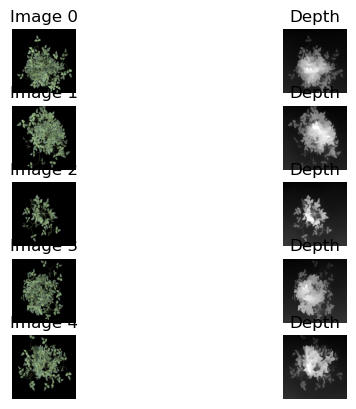

In [4]:
# Show some images
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# train_dataset = PlantDataset("../_data/Syn2Real_cowpea/Syn2Real_cowpea", plot=["000", "001", "002", "003"], transform=transform,dry_run=True,use_depth=False)

import cv2
n = 5
for i in range(n):
    image, vecs, _ = train_dataset[-i-1]
    image = image.permute(1, 2, 0)
    image_rgb = image[:, :, :3]
    img = cv2.normalize(np.array(image_rgb.cpu()), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(5, 2, 2*i+1)
    plt.imshow(img)
    plt.title(f"Image {i}")
    plt.axis('off')

    if train_dataset.use_depth:
        image_depth = image[:, :, 3]
        img = cv2.normalize(np.array(image_depth.cpu()), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        plt.subplot(5, 2, 2*i+2)
        plt.imshow(img, cmap='gray')
        plt.title("Depth")
        plt.axis('off')

In [5]:
from models.model import ImageToSequenceTransformer


model = ImageToSequenceTransformer(seq_embedding_dim=eval_config.seq_embedding_dim, 
                                   param_embedding_dim=eval_config.param_embedding_dim,
                                   num_layers=eval_config.num_layers, num_heads=eval_config.num_heads, 
                                   num_tokens=eval_config.seq_dim, num_params=eval_config.param_dim,
                                   decoder_only=True,
                                   use_depth=True,
                                   image_size=image_size)

# Test
if 0:
    train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
    for _,_,_ in train_dataloader:
        break
# Test model
if 0:
    image_paths, vectors, lengths = next(iter(train_dataloader))
    output = model(image_paths, vectors)
model = model.to(device)
#print(model)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
labes_loss_fn = nn.CrossEntropyLoss()

num_epochs = 20
model.to(device)

/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImageToSequenceTransformer(
  (cnn): CNN_ViT(
    (model): ViTModel(
      (embeddings): ViTEmbeddings(
        (patch_embeddings): ViTPatchEmbeddings(
          (projection): Conv2d(4, 768, kernel_size=(16, 16), stride=(16, 16))
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (encoder): ViTEncoder(
        (layer): ModuleList(
          (0-11): 12 x ViTLayer(
            (attention): ViTSdpaAttention(
              (attention): ViTSdpaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): ViTSelfOutput(
                (dense): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
            )
           

In [6]:
from plant_dataset import collate_fn

if 1:
    train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn, num_workers=4)
    val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn, num_workers=4)
else:
    # For debugging, set num_workers to 0
    train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
    val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)

In [7]:
train_loss_list, validation_loss_list = [], []
pretrained = True
model_save_path = '../models/checkpoints/Image2PlantArchitecture_448_20240924.pth'
if pretrained:
    model.load_state_dict(torch.load(model_save_path))

Total 384 images and plant strings loaded
camA_cowpea_010_004_0658781_RGB_00.jpeg
Ground truth
0 {5.968698,9.952922,2.977923,100.000000,unifoliate}Internode(0.020000,0.000500,0.000000,137.414311)Petiole(0.007500,0.001083,74.156128)Leaf(0.020000,-2.283459,0.000000,-9.606925)[{0.000000,0.000000,90.000000,100.000000,trifoliate}Internode(0.012000,0.001000,20.000000,135.569372)Petiole(0.110098,0.001239,48.641365)Leaf(0.048247,-18.348440,0.000000,-7.776918)Internode(0.014333,0.001000,20.000000,136.913097)Petiole(0.115295,0.001020,48.516556)Leaf(0.049512,-22.891226,0.000000,-7.181366)Internode(0.016667,0.001000,20.000000,142.336453)Petiole(0.114307,0.000878,55.744217)Leaf(0.040047,1.147330,0.000000,-16.790285)Internode(0.019000,0.001000,20.000000,141.553651)Petiole(0.109847,0.000829,57.487183)Leaf(0.041694,-3.416844,0.000000,-5.176125)[{48.872845,-9.613280,90.000000,100.000000,trifoliate}Internode(0.030667,0.001000,20.000000,130.159420)Petiole(0.104090,0.001095,53.739368)Leaf(0.044961,-4.0634

(-0.5, 447.5, 447.5, -0.5)

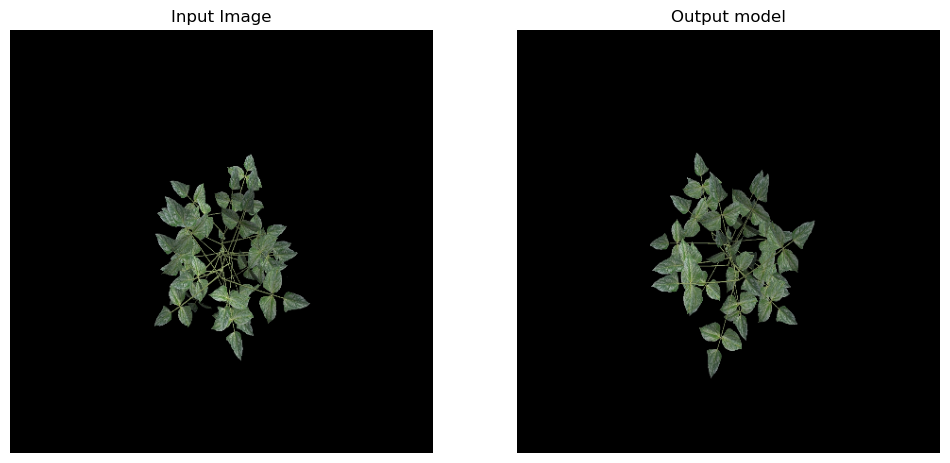

In [15]:
from plant_tokenizer import params_SOS_token_padded, SOS_token, EOS_token
from plant_tokenizer import token2vec_new as token2vec
from plant_tokenizer import vec2token_new as vec2token
from models.model import get_tgt_mask

def predict(model, images, max_length=15, SOS_token=2, EOS_token=3):
    # Assuming 'device' is defined elsewhere in your code and is a CUDA device.
    y_input = torch.tensor(params_SOS_token_padded, dtype=torch.float32)
    
    # Change to 1,1,15
    y_input = y_input.unsqueeze(0).unsqueeze(0)
    y_input = y_input.to(device)
    for i in range(max_length):
        # Get source mask
        tgt_mask = get_tgt_mask(y_input.size(1)).to(device)
        
        try:
            with torch.no_grad():
                pred = model(images, y_input, tgt_mask)
        except Exception as e:
            print(e)
            print(f"Error in {i} iteration")
            break
        label_p = pred[:,:,:eval_config.seq_dim]
        label = label_p.topk(1)[1].view(-1)[-1].item()  # num with highest probability
        params = pred[:,:,eval_config.seq_dim:]

        # Stop if model predicts end of sentencplant_structure_vit_transformer_withpsudodepth_paramEste
        # if label == EOS_token or label == PAD_token:
        if label == EOS_token:
            break

        # Make next tensor using label and params
        next_item = torch.cat((torch.tensor([[label]], dtype=torch.float32, device=device), params[-1]), dim=1).unsqueeze(0)

        # Concatenate previous input with predicted best word
        y_input = torch.cat((y_input, next_item), dim=1)

    return y_input.squeeze(0).tolist()

model.eval()

stages = ["003","010","016","023"]
test_dataset = PlantDataset("../data/generated_dataset_Sep22_black", plot=["004"],stages=stages[1],
                            transform=transform, use_depth=True, preload=False, process_leaf=False, image_size=image_size)
gen_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)

#for idx, (image, out, lengths) in enumerate(gen_dataloader):
for idx, (image, out, lengths) in enumerate(test_dataset):   
    if image.dim() == 3:
        image = image.unsqueeze(0)

    print(test_dataset.image_paths[idx])
    print("Ground truth")
    print(test_dataset.plant_string_raw)

    image = image.to(device)

    # Plot the image
    # Draw the image
    image_vis = image.squeeze(0).permute(1,2,0).cpu().numpy()
    img = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    #img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    image_vis = img.astype(np.uint8)
    # plt.imshow(image_vis)
    result = predict(model, image, max_length=2048, SOS_token=SOS_token, EOS_token=EOS_token)
    # print(f"Example {idx}")
    # print(f"Input Structure: {token2vec(out.squeeze(0).tolist())}")
    # print(f"Input Token: {out.squeeze(0).tolist()}")
    # print(f"Continuation Token: {result}")
    # print(f"Continuation Structure: {token2vec(result)}")
    # print()
    break

out = torch.tensor(out).to(device)
ground_truth = out.squeeze(0).tolist()
if 1:
    # Token to structure
    plant_vec = token2vec(result, normalize=True)
    # print(plant_vec)
    # Plant vec to string
    plant_string = vec2string([plant_vec])
else:
    # Token to structure
    plant_vec = token2vec(ground_truth, normalize=True)
    # print(plant_vec)
    # Plant vec to string
    plant_string = vec2string([plant_vec])
print("Output")
print(plant_string)

# plant_vec to xml
#xml_string = vec2xml(plant_vec)
#print(pretty_print_xml(xml_string))


# print(plant_string)
# Save plant string to text
plant_string_file_name = "plant_string.txt"
with open(plant_string_file_name, "w") as f:
    f.write(plant_string)


# Generate plant image
from plantstring2model import plantstring2model
from image_process import process_leaf_image
import cv2
import matplotlib.pyplot as plt
p2m = plantstring2model(program_path="PlantString2Model/build",program_name="PlantString2Model",display=":11.0", height=1.0,background_path="black.png" )

# Run 
p2m.run(plantstring_path=os.path.abspath("plant_string.txt"))
generated_image_path = "output/plant_string_top.jpeg"

# Load the image
img = cv2.imread(generated_image_path)
leaf_area, plant_width, plant_height, leaf_img, _ = process_leaf_image(img,sqaure_crop=True, thr = 0.2)
# Plot the processed image
# plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))


# Plot the original and processed images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Original image
axes[0].imshow(image_vis[:,:,0:3])
axes[0].set_title("Input Image")
axes[0].axis('off')

# Processed image
img = cv2.resize(img,(image_size,image_size))
axes[1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[1].set_title("Output model")
axes[1].axis('off')

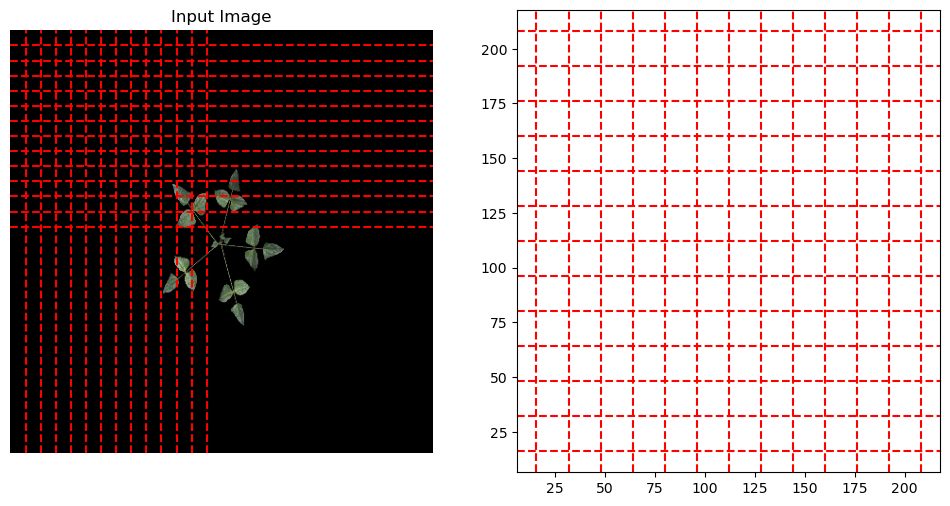

In [11]:
# Draw a 14x14 grid on the image_vis[:,:,0:3]
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_vis[:,:,0:3])
axes[0].set_title("Input Image")
axes[0].axis('off')

for i in range(1, 14):
    axes[0].axvline(i*16, color='r', linestyle='--')
    axes[0].axhline(i*16, color='r', linestyle='--')
    axes[1].axvline(i*16, color='r', linestyle='--')
    axes[1].axhline(i*16, color='r', linestyle='--')
plt.show()

['0 {3.454658,181.223114,178.348861,100.097656,unifoliate}', 'Internode(0.018615,0.000711,6.575938,144.605801)', 'Petiole(0.008802,0.000987,67.833040)', 'Leaf(0.020551,0.133739,-0.009726,0.021273)', '[{1.945474,0.034129,90.738865,100.197732,trifoliate}', 'Internode(0.011229,0.001023,20.180615,138.067862)', 'Petiole(0.111294,0.000985,53.079862)', 'Leaf(0.047527,0.277141,-0.031123,0.222312)', 'Internode(0.014316,0.001058,20.773667,142.582193)', 'Petiole(0.111579,0.000990,53.441097)', 'Leaf(0.047551,0.276080,-0.031100,0.223979)', 'Internode(0.015193,0.001069,20.959339,143.988488)', 'Petiole(0.111648,0.000993,53.610647)', 'Leaf(0.047584,0.274574,-0.031200,0.223764)', 'Internode(0.016158,0.001079,21.148883,145.439822)', 'Petiole(0.111687,0.000996,53.798316)', 'Leaf(0.047603,0.272859,-0.031413,0.223109)', 'Internode(0.013261,0.001071,21.053846,144.794601)', 'Petiole(0.111785,0.000999,53.979883)', 'Leaf(0.047603,0.271504,-0.031623,0.222510)', 'Internode(0.003298,0.000976,19.396247,132.652478)

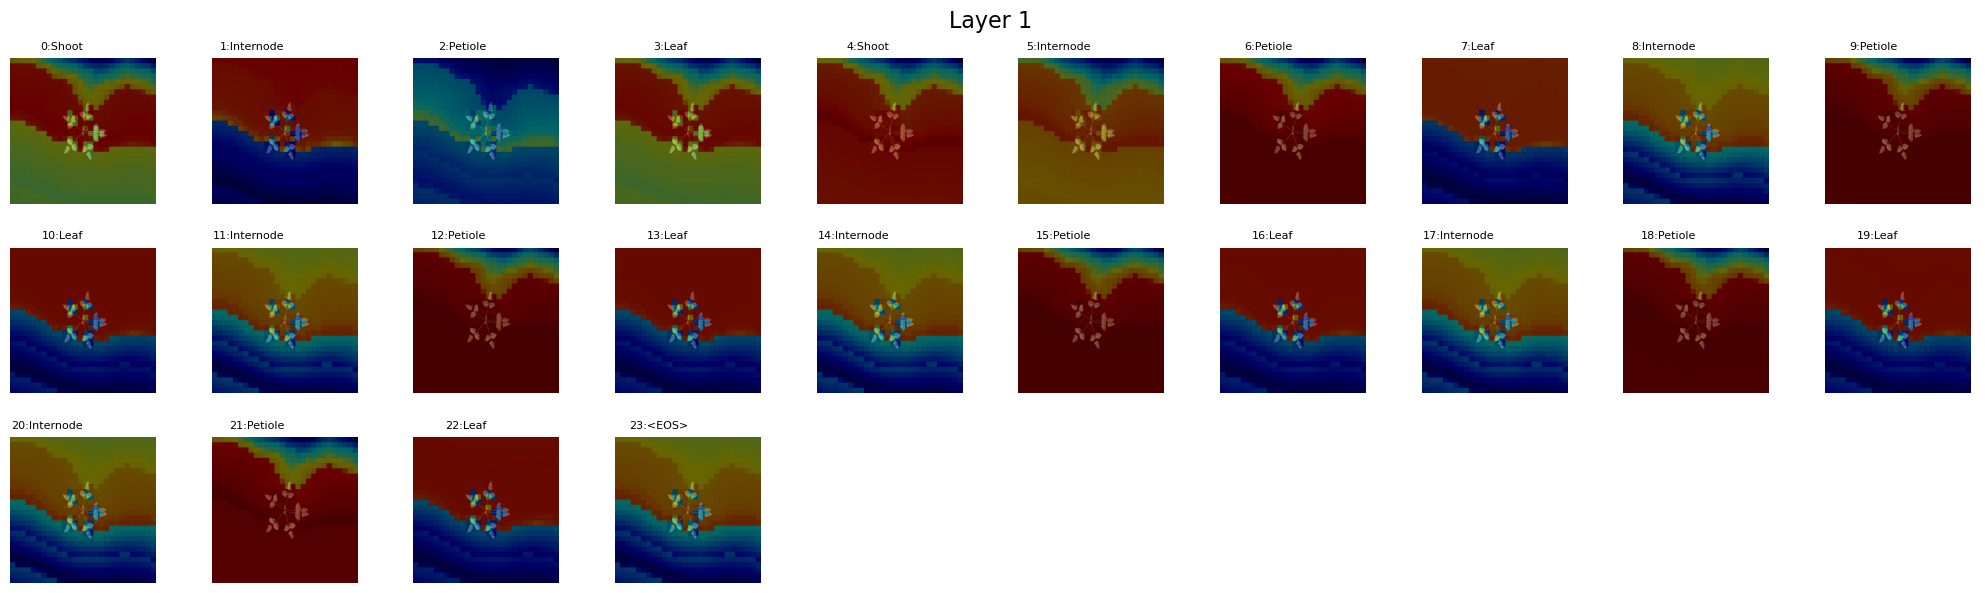

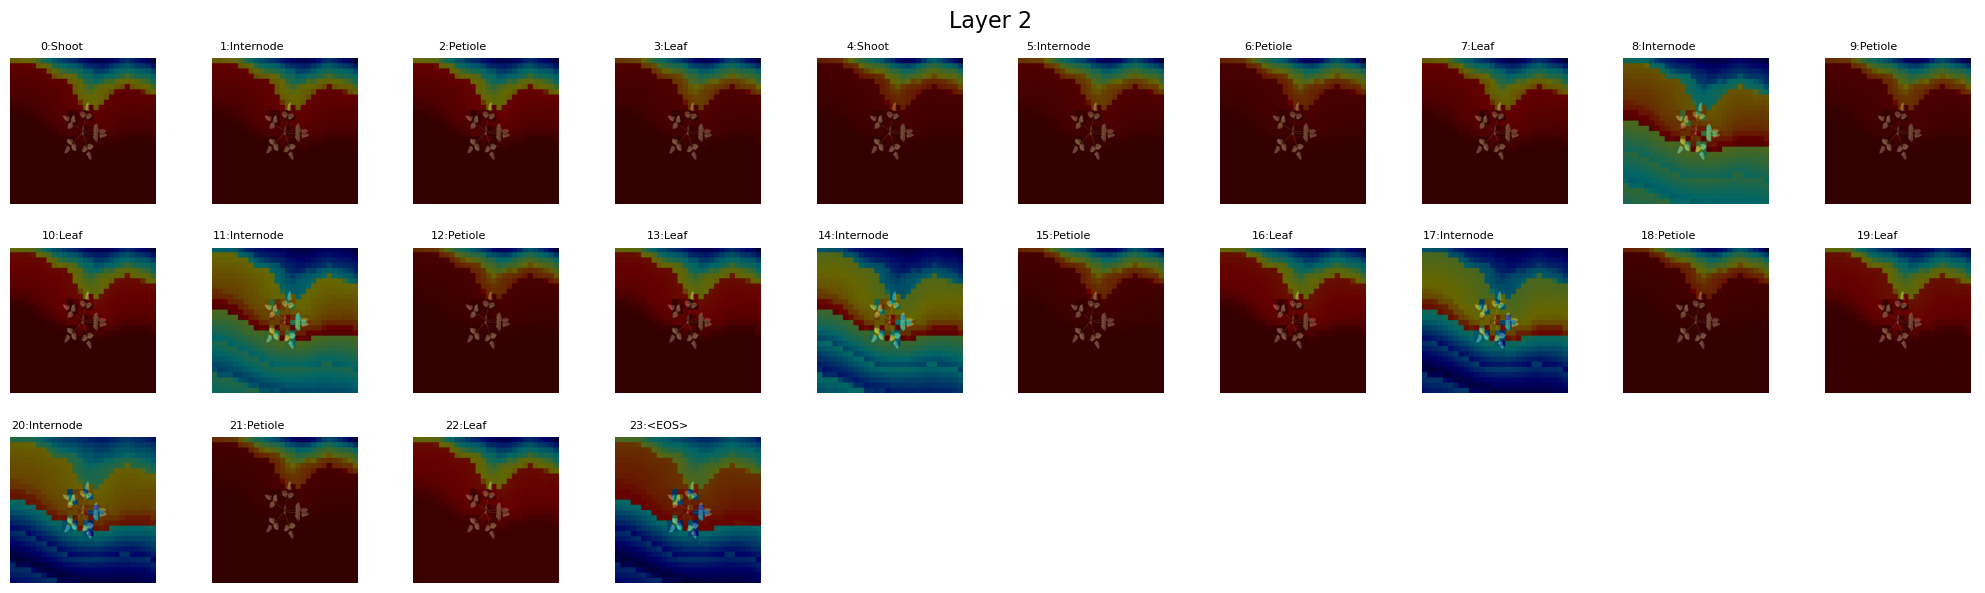

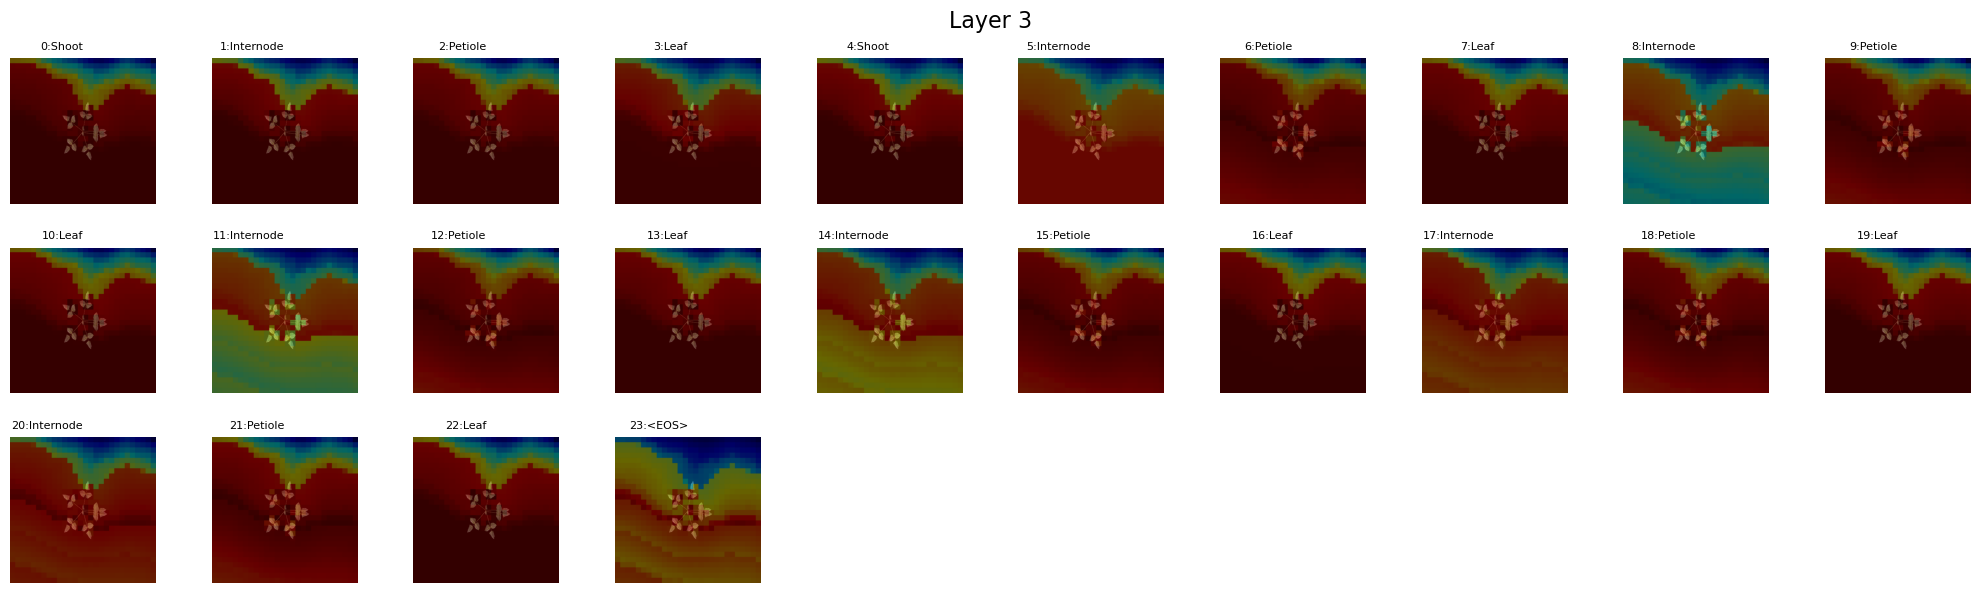

In [13]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2

from utils import visualize_attention
from string_to_xml_to_vec import plant_string2words
from plant_tokenizer import token2vec_new as token2vec

# Visualize attention
# Example words
plant_vec = token2vec(result, normalize=True)
plant_string = vec2string([plant_vec])

words = plant_string2words(plant_string)
print(words)

if 0:
    # Add <SOS> to the beginning of the list of words
    words = ["<SOS>"] + words
else:
    # Add <EOS> to the end of the list of words
    words = words + ["<EOS>"]

def shorten_title(title, max_length=10):
    """Shorten the title if it is too long."""
    if "foliate" in title:
        title = "Shoot"
    elif "Internode" in title:
        title = "Internode"
    elif "Petiole" in title:
        title = "Petiole"
    elif "Leaf" in title:
        title = "Leaf"
    return title

# Create a word_dimx3 subplot
multihead_attn_weights = model.multihead_attn_weights
image_dict = {}
num_cols = 10  # Number of images per row

for layer_index in range(len(multihead_attn_weights)):
    num_rows = (len(words) + num_cols - 1) // num_cols  # Calculate the number of rows needed
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2, num_rows * 2))
    fig.suptitle(f'Layer {layer_index + 1}', fontsize=16)
    
    for word_index in range(len(words)):
        row = word_index // num_cols
        col = word_index % num_cols
        overlay = visualize_attention(img, multihead_attn_weights, words, word_index, layer_index, interpolation=cv2.INTER_NEAREST)
        image_dict[(layer_index, word_index)] = overlay
        axes[row][col].imshow(overlay)
        axes[row][col].axis('off')
        short_title = shorten_title(words[word_index])
        axes[row][col].set_title(f"{word_index}:{short_title}", rotation=0, ha='right', fontsize=8)
    
    # Hide any unused subplots
    for i in range(len(words), num_rows * num_cols):
        row = i // num_cols
        col = i % num_cols
        axes[row][col].axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9, wspace=0.3, hspace=0.3)  # Adjust the top to make room for the suptitle and add space between subplots
    plt.show()

In [11]:
# Create a output folder
output_dir = "attention_output"
# Remove the folder if it exists
if os.path.exists(output_dir):
    import shutil
    shutil.rmtree(output_dir)
if not os.path.exists(output_dir):
    os.makedirs(output_dir)



# Save the attention images
for key, img in image_dict.items():
    layer_index, word_index = key
    img_vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    file_name = f"layer_{layer_index}_word_{word_index}_{words[word_index]}.png"
    file_path = os.path.join(output_dir, file_name)
    cv2.imwrite(file_path, img_vis)